USE CASE

User Input -> LLM(answers in english) -> LLM(translated english to hindi response) -> Hindi Response is returned as an output.

Importing all the required libraries

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

C:\Users\khana\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

Defining two states substate and parent state

Substate

In [3]:
class SubState(TypedDict):

    eng_text: str
    translated_text: str

Parentstate

In [4]:
class ParentState(TypedDict):

    user_input: str
    english_response: str
    hindi_response:str

SubGraph

In [5]:
subgraph_llm = ChatGroq(model = "LLaMA-3.1-8B-Instant")

In [9]:
def translate_to_hindi(state: SubState):

    prompt = f"Translate the following english text to hindi in proper, clean and simple manner\n {state['eng_text']}"

    translated_response = subgraph_llm.invoke(prompt).content

    return {"translated_text": translated_response}

In [7]:
sub_graph = StateGraph(SubState)

sub_graph.add_node("translate_hindi", translate_to_hindi)

sub_graph.add_edge(START, "translate_hindi")
sub_graph.add_edge("translate_hindi", END)

subgraph_compiler = sub_graph.compile()

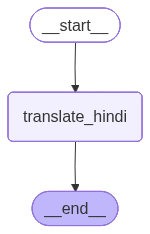

In [8]:
subgraph_compiler

Parent Graph

In [10]:
parent_llm = ChatGroq(model="LLaMA-3.1-8B-Instant")

In [11]:
def generate_reponse_in_eng(state: ParentState):

    prompt = f"Answer the following question or query in clean, simple and easy to understandable terms\n{state['user_input']}"
    eng_reponse = parent_llm.invoke(prompt).content

    return {"english_response": eng_reponse}

This function/node is a part of parentgraph but this node is further has subgraph inside parentgraph and it connects the subgraph through invoke()

In [17]:
def traslate_reponse_to_hindi(state: ParentState):

    integration_result = subgraph_compiler.invoke({"eng_text": state["english_response"]})

    return {"hindi_response": integration_result["translated_text"]}

In [18]:
parent_graph = StateGraph(ParentState)

parent_graph.add_node("generate_reponse_in_eng", generate_reponse_in_eng)
parent_graph.add_node("translate_in_hindi", traslate_reponse_to_hindi)

parent_graph.add_edge(START, "generate_reponse_in_eng")
parent_graph.add_edge("generate_reponse_in_eng", "translate_in_hindi")
parent_graph.add_edge("translate_in_hindi", END)

parentgraph_compile = parent_graph.compile()

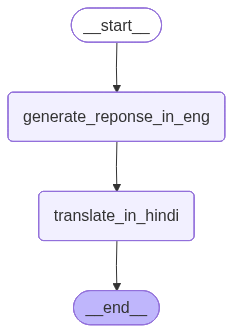

In [19]:
parentgraph_compile

Test

In [20]:
parentgraph_compile.invoke({'user_input': 'What is Agentic AI'})

{'user_input': 'What is Agentic AI',
 'english_response': '**Agentic AI** refers to Artificial Intelligence (AI) systems that are designed to act and behave like autonomous agents, capable of making decisions and taking actions on their own.\n\nThink of it like this: Imagine a robot that can navigate a room, pick up an object, and bring it to you. This robot is not just following a set of pre-programmed instructions, but it\'s making decisions in real-time, like "I see the object, I\'ll go get it, and I\'ll bring it to you."\n\nAgentic AI systems have several key characteristics:\n\n1. **Autonomy**: They can operate independently, making decisions without human intervention.\n2. **Goal-directed behavior**: They have a clear goal or objective, and they work towards achieving it.\n3. **Self-awareness**: They have a sense of their own existence and can reflect on their actions.\n4. **Proactivity**: They can take initiative and act on their own, rather than just responding to external stim